# A1 Coursework

## Question 1: Likelihood based analysis of the 21-cm power spectrum

### (a) PCA

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import os

# Load the data
data_path = "data/"
observations_data = np.load(data_path + "/observations.npz")
observations_spectrum = observations_data["power"]
observations_ks = observations_data["k"]

ks = []
spectra = []
params = []
redshift = []
code = []
code_version = []

for file in os.listdir(data_path + "/simulations/simulations/"):
    filename = os.fsdecode(file)
    if filename.endswith(".npz"): 
        sample = np.load(data_path + "/simulations/simulations/" + filename, allow_pickle=True)
        ks.append(sample[sample.files[0]])
        spectra.append(sample[sample.files[1]])

        astrophysical_params = [float(v) for v in sample[sample.files[2]].item().values()]
        cosmological_param = [float(v) for v in sample[sample.files[3]].item().values()]
        sample_params = astrophysical_params + cosmological_param
        if len(sample_params) != 4:
            raise ValueError(f"Expected 4 parameters per sample, got {len(sample_params)} for {filename}")
        params.append(sample_params)

        redshift.append(sample[sample.files[4]])
        code.append(sample[sample.files[5]])
        code_version.append(sample[sample.files[6]])
        continue
    else:
        continue

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


[0.00166234 0.00187171 0.00210745 0.00237288 0.00267174 0.00300824
 0.00338713 0.00381373 0.00429407 0.0048349  0.00544385 0.00612949
 0.0069015  0.00777073 0.00874945 0.00985143 0.0110922  0.01248925
 0.01406226 0.01583338 0.01782758 0.02007294 0.0226011  0.02544768
 0.02865278 0.03226156 0.03632487 0.04089994 0.04605123 0.05185133
 0.05838194 0.06573507 0.07401432 0.08333633 0.09383244 0.10565052
 0.11895707 0.13393956 0.15080909 0.1698033  0.19118982 0.21526993
 0.24238291 0.27291074 0.30728351 0.34598548 0.38956192 0.43862676
 0.49387125 0.55607372 0.62611051 0.70496834 0.79375823 0.89373108]
['k', 'power', 'astro_params', 'cosmo_params', 'redshfit', 'code', 'code_version']
651.2313486608382
9997 54


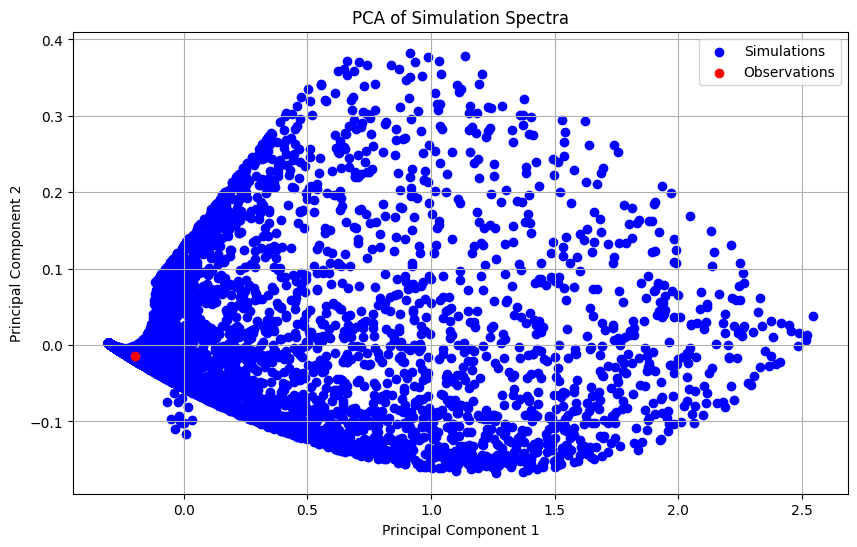

In [2]:
print(observations_ks)
print(sample.files)

max_power = np.max(spectra)
min_power = np.min(spectra)
print(max_power)
# Normalize the spectra
normalized_spectra = (spectra - min_power) / (max_power - min_power)
# Reshape the spectra for PCA
num_samples, num_features = normalized_spectra.shape
print(num_samples, num_features)
reshaped_spectra = normalized_spectra.reshape(num_samples, num_features)
normalized_observations_spectrum = (observations_spectrum - min_power) / (max_power - min_power)
# Perform PCA
pca_2 = PCA(n_components=2).fit(np.append(reshaped_spectra, normalized_observations_spectrum.reshape(1, -1), axis=0))  # Reduce to 2 dimensions for visualization
pca_2_simulations_spectra_result = pca_2.transform(reshaped_spectra)
pca_2_observations_result = pca_2.transform(normalized_observations_spectrum.reshape(1, -1))
# Plot the PCA results
plt.figure(figsize=(10, 6))
plt.scatter(pca_2_simulations_spectra_result[:, 0], pca_2_simulations_spectra_result[:, 1], c='blue', label='Simulations')
plt.scatter(pca_2_observations_result[:, 0], pca_2_observations_result[:, 1], c='red', label='Observations')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Simulation Spectra')
plt.legend()
plt.grid()
plt.show()

In [3]:
pca_54 = PCA(n_components=54)  # Reduce to 54 dimensions
pca_54_result = pca_54.fit_transform(reshaped_spectra)
print(pca_54_result.shape)
print(pca_54.explained_variance_ratio_)
print(np.cumsum(pca_54.explained_variance_ratio_))

(9997, 54)
[9.83683248e-01 1.59701021e-02 3.08602656e-04 3.79835558e-05
 5.35958706e-08 9.23860032e-09 1.55247065e-10 9.77364379e-11
 2.62700502e-11 2.41917735e-11 1.65674551e-11 1.43046072e-11
 1.12156156e-11 8.92833562e-12 7.90853301e-12 6.94055896e-12
 5.67011194e-12 4.69327603e-12 4.21970288e-12 2.28938983e-12
 1.98738873e-12 1.43492630e-12 1.25744254e-12 1.00578508e-12
 9.37985677e-13 6.72030444e-13 5.22988570e-13 4.28663079e-13
 4.20509675e-13 3.53663238e-13 2.12767465e-13 1.99873321e-13
 1.13771536e-13 4.45649439e-14 4.04899039e-14 1.51854228e-14
 8.27064208e-15 5.49147112e-16 2.10890808e-16 6.54436320e-17
 3.89589645e-17 3.63512846e-17 2.91876596e-17 1.59079456e-17
 4.03250936e-18 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00]
[0.98368325 0.99965335 0.99996195 0.99999994 0.99999999 1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1

[0.00166234 0.00187171 0.00210745 0.00237288 0.00267174 0.00300824
 0.00338713 0.00381373 0.00429407 0.0048349  0.00544385 0.00612949
 0.0069015  0.00777073 0.00874945 0.00985143 0.0110922  0.01248925
 0.01406226 0.01583338 0.01782758 0.02007294 0.0226011  0.02544768
 0.02865278 0.03226156 0.03632487 0.04089994 0.04605123 0.05185133
 0.05838194 0.06573507 0.07401432 0.08333633 0.09383244 0.10565052
 0.11895707 0.13393956 0.15080909 0.1698033  0.19118982 0.21526993
 0.24238291 0.27291074 0.30728351 0.34598548 0.38956192 0.43862676
 0.49387125 0.55607372 0.62611051 0.70496834 0.79375823 0.89373108]


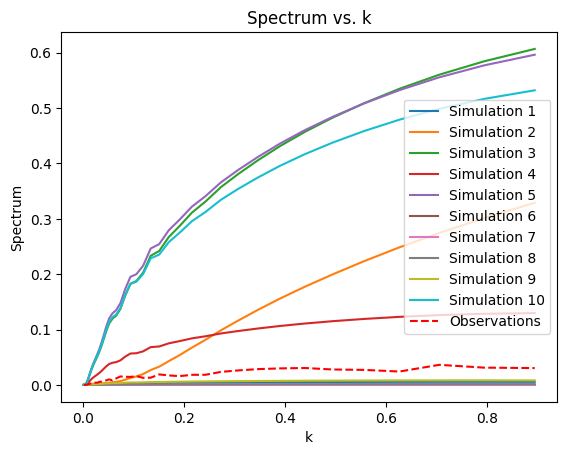

In [4]:
print(ks[0])

for i in range(10):
    plt.plot(ks[i], reshaped_spectra[i], label=f"Simulation {i+1}")

plt.plot(observations_ks, normalized_observations_spectrum, label="Observations", linestyle='dashed', color='red')

#plt.plot(labels, observations, label="Observations", linestyle='dashed')
plt.xlabel("k")
plt.ylabel("Spectrum")
plt.title("Spectrum vs. k")
plt.legend()
plt.show()

We use 2 principal components, which together explain $>99.96\%$ of the variance in the data. We now split the normalised and decomposed simulations into training, validation, and testing samples using an 80:10:10 split. We also apply the same normalisation and PCA reduction to the observed power spectrum.

In [5]:
# Split the data into training, validation, and test sets with 80-10-10 split
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(params, pca_2_simulations_spectra_result, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
print(f"Training set size: {np.shape(X_train)[0]}")
print(f"Validation set size: {np.shape(X_val)[0]}")
print(f"Test set size: {np.shape(X_test)[0]}")

# Save the split datasets in the data directory under the name "train.npz", "val.npz", and "test.npz"
np.savez(data_path + "train.npz", X_train=X_train, y_train=y_train)
np.savez(data_path + "val.npz", X_val=X_val, y_val=y_val)
np.savez(data_path + "test.npz", X_test=X_test, y_test=y_test)

# Save the normalized and transformed observations spectrum in the data directory under the name "observations_pca.npz"
np.savez(data_path + "observations_pca.npz", observations_pca=pca_2_observations_result)

# Save the PCA model for later use
import joblib
joblib.dump(pca_2, data_path + "pca_model.pkl")

Training set size: 7997
Validation set size: 1000
Test set size: 1000


['data/pca_model.pkl']

### (b)

The data is normalised by subtracting the minimum power in the simulations and dividing by the difference between the maximum power and the minimum power in the simulations.

In [ ]:
import torch

# Build a neural network that takes 4 input features and outputs the 2 PCA components
class SimpleNN(torch.nn.Module):
    def __init__(self, n_hidden_units_1=128, n_hidden_units_2=128, n_hidden_units_3=32):
        super(SimpleNN, self).__init__()
        self.fc1 = torch.nn.Linear(4, n_hidden_units_1)
        self.fc2 = torch.nn.Linear(n_hidden_units_1, n_hidden_units_2)
        self.fc3 = torch.nn.Linear(n_hidden_units_2, n_hidden_units_3)
        self.fc4 = torch.nn.Linear(n_hidden_units_3, 2)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)
        return x
    
model = SimpleNN()
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# Convert the training data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)
# Train the model
num_epochs = 200
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    # Compute validation loss every 10 epochs
    if (epoch+1) % 10 == 0:
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_tensor)
            val_loss = criterion(val_outputs, y_val_tensor)
        model.train()  # Set back to training mode
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, Validation Loss: {val_loss.item():.4f}")

Epoch [10/200], Loss: 0.1237, Validation Loss: 0.1070
Epoch [20/200], Loss: 0.0952, Validation Loss: 0.0800
Epoch [30/200], Loss: 0.0534, Validation Loss: 0.0424
Epoch [40/200], Loss: 0.0182, Validation Loss: 0.0137
Epoch [50/200], Loss: 0.0090, Validation Loss: 0.0074
Epoch [60/200], Loss: 0.0067, Validation Loss: 0.0058
Epoch [70/200], Loss: 0.0054, Validation Loss: 0.0047
Epoch [80/200], Loss: 0.0044, Validation Loss: 0.0039
Epoch [90/200], Loss: 0.0036, Validation Loss: 0.0031
Epoch [100/200], Loss: 0.0030, Validation Loss: 0.0026
Epoch [110/200], Loss: 0.0024, Validation Loss: 0.0022
Epoch [120/200], Loss: 0.0020, Validation Loss: 0.0018
Epoch [130/200], Loss: 0.0017, Validation Loss: 0.0016
Epoch [140/200], Loss: 0.0019, Validation Loss: 0.0015
Epoch [150/200], Loss: 0.0015, Validation Loss: 0.0013
Epoch [160/200], Loss: 0.0012, Validation Loss: 0.0012
Epoch [170/200], Loss: 0.0011, Validation Loss: 0.0010
Epoch [180/200], Loss: 0.0010, Validation Loss: 0.0010
Epoch [190/200], Lo

In [12]:
# Optimize the model hyperparameters using Optuna
import optuna

def objective(trial):
    n_hidden_units_1 = trial.suggest_categorical('n_hidden_units_1', [16, 32, 64, 128, 256])
    n_hidden_units_2 = trial.suggest_categorical('n_hidden_units_2', [16, 32, 64, 128, 256])
    n_hidden_units_3 = trial.suggest_categorical('n_hidden_units_3', [16, 32, 64, 128, 256])
    model = SimpleNN(n_hidden_units_1, n_hidden_units_2, n_hidden_units_3)
    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    num_epochs = 200
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
    return val_loss.item()

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)
print("Best hyperparameters: ", study.best_params)

[I 2026-03-17 11:27:09,991] A new study created in memory with name: no-name-bccfc3bd-3e37-4d96-8a20-f6369390798d
[I 2026-03-17 11:27:11,921] Trial 0 finished with value: 0.00052307837177068 and parameters: {'n_hidden_units_1': 64, 'n_hidden_units_2': 128, 'n_hidden_units_3': 128}. Best is trial 0 with value: 0.00052307837177068.
[I 2026-03-17 11:27:12,636] Trial 1 finished with value: 0.0015869709895923734 and parameters: {'n_hidden_units_1': 64, 'n_hidden_units_2': 16, 'n_hidden_units_3': 64}. Best is trial 0 with value: 0.00052307837177068.
[I 2026-03-17 11:27:13,323] Trial 2 finished with value: 0.0015285026747733355 and parameters: {'n_hidden_units_1': 128, 'n_hidden_units_2': 32, 'n_hidden_units_3': 32}. Best is trial 0 with value: 0.00052307837177068.
[I 2026-03-17 11:27:20,533] Trial 3 finished with value: 0.00022826631902717054 and parameters: {'n_hidden_units_1': 256, 'n_hidden_units_2': 256, 'n_hidden_units_3': 256}. Best is trial 3 with value: 0.00022826631902717054.
[I 202

Best hyperparameters:  {'n_hidden_units_1': 256, 'n_hidden_units_2': 256, 'n_hidden_units_3': 256}
